# Zero-Train Optimization & Maintenance (ZTOM) of a Military Aircraft Identification CNN

**MilAir (Military Aircraft Classification Model)**

**Note: This demo uses publicly available aircraft types for classification purposes. No sensitive or classified military information is included.**

## Background

The MilAir CNN is a convolutional neural network classifier trained on approximately 90,000 military aircraft images to identify 20 different aircraft classes. The model was trained across 7 checkpoints, representing different stages of the training process. This demo showcases how ZTOM can optimize the model's performance without requiring any additional training data or retraining.

**Dataset:** https://www.kaggle.com/datasets/a2015003713/militaryaircraftdetectiondataset

## Scenario

After initial training, the model may benefit from optimization to improve its classification accuracy and confidence. Traditional approaches would require retraining the model with additional data, which is time-consuming and computationally expensive. ZTOM provides an alternative solution that optimizes the model's performance using only a small validation set and a selected loss/error function.

## Use Case

This demonstration is applicable when:
- A model is already trained and deployed, but performance improvements are desired
- Retraining is not feasible due to time, computational, or data constraints
- You have access to only a small validation set (e.g., 8 images per class)

## Summary

This notebook demonstrates how the Zero-Train Optimization & Maintenance (ZTOM) improves the Military Aircraft (MilAir) CNN model's ability to identify aircraft classes with higher confidence and accuracy, without requiring any retraining. Using a minimal validation set of only 8 images per class (160 images total across 20 aircraft classes), ZTOM reduced the model's cross-entropy loss by approximately 10.78%, demonstrating significant performance gains with minimal data requirements.
  
## ZTOM Result Outputs

  | Metric                       | Value                                     |
  |------------------------------|------------------------------------------:|
  | Non-Optimized Model Error    | 1.533                                     |
  | Optimized Model Error        | 1.328                                     |
  | Improvement                  | ~10.78%                                   |
  | Scaling Factors              | [-0.017,0.007,-0.068,-0.006,-0.052,-0.177]|
  | Number of Inferences         | 63                                        |

## Setup

### Install dependencies and utility functions: This cell should be run once.

In [1]:
%%capture

%pip install matplotlib numpy pandas requests tqdm ipywidgets
%pip install --ignore-installed 'git+https://github.com/Authentrics-ai/authentrics-client.git@v2.4.1'
%pip install torch @ 'https://download.pytorch.org/whl/cpu/torch-2.8.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl#sha256=cb9a8ba8137ab24e36bf1742cb79a1294bd374db570f09fc15a5e1318160db4e'

import authentrics_client as authrx
import contextlib
import csv
import ipywidgets as widgets
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import requests
import torch
import time
from datetime import datetime
from IPython.display import display, HTML, clear_output
from pathlib import Path
from PIL import Image
from threading import Thread
from tqdm.notebook import tqdm

# Utility functions for loading indicators
@contextlib.contextmanager
def loading_spinner(message="Processing..."):
    """Context manager for showing a loading spinner"""
    spinner_widget = widgets.HTML(value=f"""
    <div style="display: flex; align-items: center; gap: 10px;">
        <div style="width: 20px; height: 20px; border: 2px solid #f3f3f3; border-top: 2px solid #3498db; border-radius: 50%; animation: spin 1s linear infinite;"></div>
        <span style="font-size: 14px; color: #555;">{message}</span>
    </div>
    <style>
    @keyframes spin {{
        0% {{ transform: rotate(0deg); }}
        100% {{ transform: rotate(360deg); }}
    }}
    </style>
    """)
    display(spinner_widget)
    try:
        yield
    finally:
        spinner_widget.close()

def show_progress_bar(total, description="Progress"):
    """Create and return a progress bar"""
    return tqdm(total=total, desc=description, bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')

def wait_for_analytics(project_id, min_wait_time=30, max_wait_time=300, check_interval=10):
    """
    Wait for ALL analytics to be complete before continuing.
    This prevents NaN values from appearing in the summary table.
    """
    import time

    print("🔄 Waiting for analytics to process...")
    countdown_widget = widgets.HTML()
    display(countdown_widget)

    # Minimum wait with countdown
    for remaining in range(min_wait_time, 0, -1):
        countdown_widget.value = f"""
        <div style="display: flex; align-items: center; gap: 10px; margin: 10px 0;">
            <div style="width: 20px; height: 20px; border: 2px solid #f3f3f3; border-top: 2px solid #3498db; border-radius: 50%; animation: spin 1s linear infinite;"></div>
            <span style="font-size: 14px; color: #555;">Minimum wait period: {remaining} seconds remaining...</span>
        </div>
        <style>
        @keyframes spin {{
            0% {{ transform: rotate(0deg); }}
            100% {{ transform: rotate(360deg); }}
        }}
        </style>
        """
        time.sleep(1)

    # Poll until ALL analytics are complete
    start_polling = time.time()
    attempt = 1

    while (time.time() - start_polling) < (max_wait_time - min_wait_time):
        try:
            project = client.project.get_project_by_id(project_id)
            files = project["fileList"][1:]  # Skip base model

            # Check that ALL files have both weight and bias contributions
            files_missing_analytics = []
            for f in files:
                if (f.get("totalWeightContribution") is None or
                    f.get("totalBiasContribution") is None):
                    files_missing_analytics.append(f["fileName"])

            # Only continue if ALL analytics are complete
            if not files_missing_analytics:
                countdown_widget.value = """
                <div style="color: green; font-weight: bold; margin: 10px 0;">
                    ✅ All analytics are complete!
                </div>
                """
                return True

            # Show progress with specific missing files
            total_files = len(files)
            completed_files = total_files - len(files_missing_analytics)
            progress_pct = (completed_files / total_files * 100) if total_files > 0 else 0

            missing_display = ', '.join(files_missing_analytics[:3])
            if len(files_missing_analytics) > 3:
                missing_display += f" and {len(files_missing_analytics) - 3} more"

            countdown_widget.value = f"""
            <div style="display: flex; align-items: center; gap: 10px; margin: 10px 0;">
                <div style="width: 20px; height: 20px; border: 2px solid #f3f3f3; border-top: 2px solid #orange; border-radius: 50%; animation: spin 1s linear infinite;"></div>
                <span style="font-size: 14px; color: #555;">
                    Attempt {attempt}: {completed_files}/{total_files} files complete ({progress_pct:.1f}%)
                    <br/>⏳ Waiting for: {missing_display}
                </span>
            </div>
            <style>
            @keyframes spin {{
                0% {{ transform: rotate(0deg); }}
                100% {{ transform: rotate(360deg); }}
            }}
            </style>
            """
            attempt += 1
            time.sleep(check_interval)

        except Exception as e:
            print(f"⚠️ Error checking analytics status: {e}")
            time.sleep(check_interval)

    # Timeout reached - show final status
    try:
        project = client.project.get_project_by_id(project_id)
        files = project["fileList"][1:]
        files_missing_analytics = [f["fileName"] for f in files
                                 if (f.get("totalWeightContribution") is None or
                                     f.get("totalBiasContribution") is None)]

        if files_missing_analytics:
            countdown_widget.value = f"""
            <div style="color: red; font-weight: bold; margin: 10px 0;">
                ⚠️ Timeout: Analytics incomplete for {len(files_missing_analytics)} files.
                <br/>NaN values will appear for: {', '.join(files_missing_analytics[:5])}
                <br/>Consider increasing wait time or contacting support.
            </div>
            """
            return False
        else:
            countdown_widget.value = """
            <div style="color: green; font-weight: bold; margin: 10px 0;">
                ✅ All analytics completed just in time!
            </div>
            """
            return True
    except Exception as e:
        countdown_widget.value = f"""
        <div style="color: red; font-weight: bold; margin: 10px 0;">
            ❌ Error checking final status: {e}
        </div>
        """
        return False


def display_static_analysis_results(result: dict):
    print(f"Weight summary score: {result['weight_summary_score']}")
    pd.options.display.max_rows = None


    methods = {"min": np.amin, "mean": np.mean, "std": np.std, "max": np.amax}
    awd = {"name": [], "min": [], "mean": [], "std": [], "max": []}

    for name, values in response["result"]["absolute_weight_difference"].items():
        awd["name"].append(name)
        for method_name, method in methods.items():
            awd[method_name].append(method(values))

    df = pd.DataFrame(awd)
    display(df)


def get_stimulus_paths(output_filename: str):
    GITHUB_BASE_URL = "https://raw.githubusercontent.com/Authentrics-ai/demos/refs/heads/feature/AA-1128-ZTO-demo/ZeroTrain_Optimizer_And_Maintenance/MilitaryAircraft/stimuli"
    output_filename_url = f"{GITHUB_BASE_URL}/{output_filename}"
    response = requests.get(output_filename_url)
    filenames = [line.strip() for line in response.text.split('\n') if line.strip()]

    # Generate stimulus paths for each filename in the GCS bucket
    return [f"demo-models/MilAir/stimuli/{filename}" for filename in filenames]

def display_sample_image(stimulus_path: str, stimulus_name: str):
    image = Image.open(stimulus_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Sample Image: {stimulus_name}")
    plt.show()

def softmax(x):
    """Compute softmax of a 1D array"""
    e = np.exp(x - np.max(x))  # Subtract max for numerical stability
    return e / np.sum(e, axis=-1)

def display_single_inference_results(results_dict: dict, classes: list[str]):
    """Display model prediction results in a table using Pandas"""
    series = {}
    for col_name, logits in results_dict.items():
        arr = np.asarray(logits).flatten()
        series[col_name] = softmax(arr) * 100

    return pd.DataFrame(series, index=classes)

### Contact Authentrics for the URL and user credentials info@authentrics.ai

In [2]:

DEMO_SERVER_URL = input("Enter your Authentrics URL: ")
PROJECT_NAME = "Military Aircraft ZTOM"
pd.options.display.precision = 3
pd.options.display.chop_threshold = None

classes = [
    "A10", "AH64", "B1", "B52",
    "C130", "C17", "C2", "EF2000",
    "F15", "F16", "F18", "F22",
    "F35", "F4", "J10", "J20",
    "JAS39", "Rafale", "US2", "V22",
]

### Establish a session with authentrics
- Rerun this cell if your session expires

In [3]:
client = authrx.AuthentricsClient(DEMO_SERVER_URL)
client.auth.login()
print("✅ Session established successfully!")

✅ Session established successfully!


### Generate a project in Authentrics to track checkpoints, and perform asynchronous analytics
1. Creates a project for checkpoint management.
2. **Option A**: Point to existing checkpoint storage (no data movement required).
3. **Option B**: Upload checkpoints directly through our client (automated storage and versioning).

In [4]:
projects = client.project.get_projects()
if projects is not None:
    project = next((p for p in projects if p["name"].startswith(PROJECT_NAME)), None)
    if project:
        client.project.delete_project(project["id"], hard_delete=True)

PROJECT_NAME = PROJECT_NAME + " " + str(int(datetime.now().timestamp()))
project = client.project.create_project(
    PROJECT_NAME,
    "A classification CNN to identify select military aircraft",
    authrx.FileType.ONNX,
)
project_id = project["id"]

### Restore all checkpoint files, stimulus files, and expected output file in bucket to a stable version

In [5]:
with loading_spinner("Please wait while we restore the requested files..."):
    client.get('/transfer/MilAir')

### Point authentrics file registry to the checkpoints using the api

In [6]:
from time import sleep


print("Adding checkpoints to project...")
with show_progress_bar(7, "Adding checkpoints") as pbar:
    for i in range(7):
        client.checkpoint.add_external_checkpoint(
            project_id,
            f"demo-models/MilAir/validated_checkpoints/checkpoint_{i+1}.onnx",
            authrx.FileType.ONNX,
            file_name=f"checkpoint_{i+1}.onnx",
            tag=f"v{i+1}",
        )
        pbar.update(1)
        sleep(1)
project = client.project.get_project_by_id(project_id)
print(f"Project created with id: {project_id}")
print(f"Project name: {project['name']}")
for file in project["fileList"]:
    print(f"File name: {file["fileName"]}")

Project created with id: 6970e4cffb2cee375a6181ef
Project name: Military Aircraft ZTOM 1769006287
File name: checkpoint_1.onnx
File name: checkpoint_2.onnx
File name: checkpoint_3.onnx
File name: checkpoint_4.onnx
File name: checkpoint_5.onnx
File name: checkpoint_6.onnx
File name: checkpoint_7.onnx


Wait for Analytics to be ready before proceeding.

In [7]:
print("\n" + "="*60)
print("📊 ANALYTICS PROCESSING")
print("="*60)
print("Authentrics is now computing analytics in the background.")
print("This includes weight contributions and bias scores for each checkpoint.")

analytics_ready = wait_for_analytics(project_id, min_wait_time=10, max_wait_time=300)
if not analytics_ready:
    print("\n❌ Analytics are not complete.")
    print("Please wait a moment longer and then continue. Please contact support if the issue persists.")

## Zero-Train Optimization & Maintenance (ZTOM) Results

Authentrics.ai provides a ZTOM service that allows you to optimize a model's performance without additional training.

This will increase or decrease the effects of each training iteration on the model to obtain the best possible performance. In this case, the performance is measured by cross entropy between the model's output and the expected output.

The scaling factor limit is the maximum fraction of change that any one training iteration can undergo. In this case, each training iteration can only change by 20% of its original effect.

In [8]:
%%time
# Variants available: 40, 80, 160, 200, 320, 400, validate(13089)
variant = "160"
# Generate stimulus paths for each filename in the GCS bucket
stimulus_paths = get_stimulus_paths(f"stimulus-filenames-{variant}.txt")
expected_output_path = f"demo-models/MilAir/stimuli/expected-output-{variant}.csv"

with loading_spinner("Running zero-train optimization and maintenance..."):
    response = client.dynamic.zero_train_optimizer(
        project_id=project["id"],
        scaling_factor_limit=0.2,
        stimulus_paths=stimulus_paths,
        batch_size=40,
        expected_output_path=expected_output_path,
    detailed_output="STORE_AND_RETURN"
)

result = response["result"]

print(result)

{'trained_model_error': 1.533253312664916, 'optimized_model_error': 1.3278569862409575, 'optimized_scaling_factors': [-0.01686977561166047, 0.006933071169986073, -0.06824078352483062, -0.005717189423067364, -0.05198357274759268, -0.1769015978304454], 'number_of_inferences': 63}
CPU times: user 23.4 ms, sys: 11.2 ms, total: 34.6 ms
Wall time: 2min 43s


### Result details

`trained_model_error` is the cross-entropy loss between the non-optimized model's output and the expected output.

In [9]:
result["trained_model_error"]

1.533253312664916

`optimized_model_error` is the cross-entropy loss between the optimized model's output and the expected output.

In [10]:
result["optimized_model_error"]

1.3278569862409575

`optimized_scaling_factors` is the scaling factor for each training iteration that was applied to the model to produce the optimized model.

In [11]:
result["optimized_scaling_factors"]

[-0.01686977561166047,
 0.006933071169986073,
 -0.06824078352483062,
 -0.005717189423067364,
 -0.05198357274759268,
 -0.1769015978304454]

`number_of_inferences` is the number of inferences that were performed to produce the optimized model.

In [12]:
result["number_of_inferences"]

63

### Inference the non-optimized and optimized models

In [13]:
stimulus_name = "F18.jpg"
os.makedirs("stimuli", exist_ok=True)
!wget -O stimuli/{stimulus_name} https://raw.githubusercontent.com/Authentrics-ai/demos/main/MilitaryAircraft/sample_images/{stimulus_name}
stimulus_path = f"stimuli/{stimulus_name}"

Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3979 (3.9K) [image/jpeg]
Saving to: ‘stimuli/F18.jpg’

stimuli/F18.jpg saved [3979/3979]



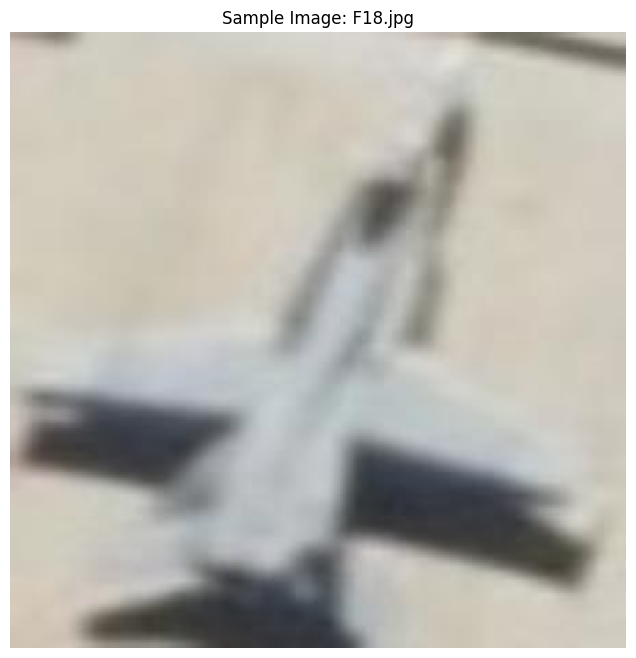


Model Prediction Probabilities:


,Non-Optimized (%),Optimized (%)
A10,5.748e-03,1.195e-02
AH64,1.752e-04,6.676e-04
B1,3.808e-04,9.649e-04
B52,1.961e-04,3.740e-04
C130,5.062e-04,1.775e-03
C17,2.527e-04,6.479e-04
C2,2.128e-04,6.825e-04
EF2000,9.810e-04,2.467e-03
F15,3.498e-03,9.130e-03
F16,2.979e-03,8.054e-03



Non-Optimized Model - Top Prediction: F18 (99.98%)
Optimized Model - Top Prediction: F18 (99.95%)
CPU times: user 87.4 ms, sys: 25.7 ms, total: 113 ms
Wall time: 16.8 s


In [14]:
%%time
stored_results = client.result.getAnalysisResults(project["id"])

optimized_model_path = f"{project_id}/results/{stored_results[-1]["requestId"]}.onnx"
non_optimized_model_path = client.project.get_project_by_id(project_id)['fileList'][-1]['filePath']

non_optimized_response = client.dynamic.direct_inference(
    model_path=non_optimized_model_path,
    stimulus_path=stimulus_path,
    format="ONNX"
)
optimized_response = client.dynamic.direct_inference(
    model_path=optimized_model_path,
    stimulus_path=stimulus_path,
    format="ONNX"
)

non_optimized_output = non_optimized_response["result"]["output"]
optimized_output = optimized_response["result"]["output"]

# Display the results as a comparison table
results_df = display_single_inference_results({
    "Non-Optimized (%)": non_optimized_output,
    "Optimized (%)": optimized_output
}, classes)

display_sample_image(stimulus_path, stimulus_name)
print("\nModel Prediction Probabilities:")
display(results_df)

# Show the top predictions
print(f"\nNon-Optimized Model - Top Prediction: {classes[np.argmax(non_optimized_output)]} ({np.max(softmax(np.array(non_optimized_output))):.2%})")
print(f"Optimized Model - Top Prediction: {classes[np.argmax(optimized_output)]} ({np.max(softmax(np.array(optimized_output))):.2%})")

## Example of error function used to optimize the model

In [15]:
def compute_error_score_torch(model_outputs, expected_outputs):

    return torch.nn.functional.cross_entropy(torch.tensor(model_outputs), torch.tensor(expected_outputs), reduction='none')

### Load stimuli and expected outputs

In [16]:
# Variants available: 40, 80, 160, 200, 320, 400, validate(13089)
variant = "validate"
stimulus_paths = get_stimulus_paths(f"stimulus-filenames-{variant}.txt")

# Read expected outputs (class labels) from CSV and parse into arrays
!wget -O stimuli/expected-output-{variant}.csv https://raw.githubusercontent.com/Authentrics-ai/demos/refs/heads/feature/AA-1128-ZTO-demo/ZeroTrain_Optimizer_And_Maintenance/MilitaryAircraft/stimuli/expected-output-{variant}.csv
expected_outputs = np.loadtxt(f"stimuli/expected-output-{variant}.csv", delimiter=',')

### Inference the models to get the model outputs

In [17]:
%%time
# Inference the non-optimized model
non_optimized_response = client.dynamic.batch_direct_inference(
    model_path=non_optimized_model_path,
    stimulus_paths=stimulus_paths,
    format="ONNX",
    batch_size=100
)

# Inference the optimized model
optimized_response = client.dynamic.batch_direct_inference(
    model_path=optimized_model_path,
    stimulus_paths=stimulus_paths,
    format="ONNX",
    batch_size=100
)

CPU times: user 261 ms, sys: 130 ms, total: 391 ms
Wall time: 41min 18s


### Scored outputs using cross-entropy loss

In [18]:
# Compute per-sample losses
non_optimized_losses = compute_error_score_torch(non_optimized_response["result"]["output"], expected_outputs)
optimized_losses = compute_error_score_torch(optimized_response["result"]["output"], expected_outputs)

# Get the true class for each sample (from expected_outputs)
true_classes = [classes[np.argmax(label)] for label in expected_outputs]

# Create DataFrame with per-sample data
sample_df = pd.DataFrame({
    "true_class": true_classes,
    "non_optimized_loss": non_optimized_losses,
    "optimized_loss": optimized_losses
})

# Group by true class and compute all statistics in one pass
class_results = sample_df.groupby("true_class").agg({
    "non_optimized_loss": ["mean", "count"],  # Get mean and count from same column
    "optimized_loss": "mean"
}).reset_index()

# Flatten column names
class_results.columns = ["image_class", "non_optimized_model_score", "number_of_images", "optimized_model_score"]

# Add improvement column
class_results["improvement"] = class_results["non_optimized_model_score"] - class_results["optimized_model_score"]

# Reorder columns and sort
class_results = class_results[["image_class", "number_of_images", "non_optimized_model_score", "optimized_model_score", "improvement"]]
class_results = class_results.sort_values("image_class").reset_index(drop=True)

display(class_results)

# Overall statistics
print(f"\nOverall average loss - Non-optimized: {non_optimized_losses.mean():.3f}")
print(f"Overall average loss - Optimized: {optimized_losses.mean():.3f}")
print(f"Overall loss improvement: {(non_optimized_losses - optimized_losses).mean():.3f}")
print(f"Overall loss percentage improvement: {(non_optimized_losses - optimized_losses).mean() / non_optimized_losses.mean() * 100:.2f}%")

,image_class,number_of_images,non_optimized_model_score,optimized_model_score,improvement
0,A10,486,1.177,1.037,0.140
1,AH64,330,1.304,1.092,0.213
2,B1,516,1.769,1.626,0.144
3,B52,552,1.354,1.250,0.104
4,C130,924,0.885,0.778,0.107
5,C17,492,2.121,2.028,0.094
6,C2,516,1.828,1.639,0.189
7,EF2000,594,1.199,0.950,0.249
8,F15,1026,0.758,0.842,-0.084
9,F16,1387,1.996,1.747,0.248



Overall average loss - Non-optimized: 1.472
Overall average loss - Optimized: 1.313
Overall loss improvement: 0.159
Overall loss percentage improvement: 10.78%


## Analyze the ZTOM model

Upload the optimized model to the project


In [19]:
project = client.checkpoint.add_external_checkpoint(
    project_id,
    optimized_model_path,
    authrx.FileType.ONNX,
    file_name="optimized_model.onnx",
    tag="optimized",
)
checkpoint_id = project["fileList"][-1]["id"]

Wait for analytics to be ready


In [20]:
analytics_ready = wait_for_analytics(project_id, min_wait_time=10, max_wait_time=300)

Run static analysis on the optimized model

In [21]:
%%time
print("Running static analysis...")
with loading_spinner("Running static analysis..."):
    response = client.static.static_analysis(
        project_id=project_id,
        checkpoint_id=checkpoint_id,
    )
print("✅ Static analysis complete")

Running static analysis...


✅ Static analysis complete
CPU times: user 71.8 ms, sys: 29 ms, total: 101 ms
Wall time: 2.82 s


In [22]:
display_static_analysis_results(response["result"])


Weight summary score: 0.003235705429688096


,name,min,mean,std,max
0,squeeze_edit_model.features.0.0.weight,-9.282e-02,-6.465e-05,1.422e-02,1.741e-01
1,squeeze_edit_model.features.1.0.block.0.0.weight,-1.313e+00,5.503e-03,2.299e-01,1.487e+00
2,squeeze_edit_model.features.1.0.block.1.fc1.we...,-2.665e-02,-1.501e-03,3.919e-03,1.107e-02
3,squeeze_edit_model.features.1.0.block.1.fc2.we...,-2.328e-02,-1.815e-03,4.549e-03,6.353e-03
4,squeeze_edit_model.features.1.0.block.2.0.weight,-6.213e-02,-1.037e-04,1.076e-02,5.744e-02
5,squeeze_edit_model.features.1.1.block.0.0.weight,-2.395e-01,5.330e-04,3.195e-02,1.894e-01
6,squeeze_edit_model.features.1.1.block.1.fc1.we...,-4.269e-02,-1.614e-03,8.300e-03,2.504e-02
7,squeeze_edit_model.features.1.1.block.1.fc2.we...,-4.391e-02,-5.542e-03,8.805e-03,2.010e-02
8,squeeze_edit_model.features.1.1.block.2.0.weight,-4.306e-01,2.469e-03,7.302e-02,3.645e-01
9,squeeze_edit_model.features.2.0.block.0.0.weight,-3.092e-03,2.842e-05,7.175e-04,4.143e-03


## Summary

This notebook demonstrates how the Zero-Train Optimization & Maintenance (ZTOM) improves the Military Aircraft (MilAir) CNN model's ability to identify aircraft classes with higher confidence and accuracy, without requiring any retraining. Using a minimal validation set of only 8 images per class (160 images total across 20 aircraft classes), ZTOM reduced the model's cross-entropy loss by approximately 10.78%, demonstrating significant performance gains with minimal data requirements.
  
## ZTOM Result Outputs

  | Metric                       | Value                                     |
  |------------------------------|------------------------------------------:|
  | Non-Optimized Model Error    | 1.533                                     |
  | Optimized Model Error        | 1.328                                     |
  | Improvement                  | ~10.78%                                   |
  | Scaling Factors              | [-0.017,0.007,-0.068,-0.006,-0.052,-0.177]|
  | Number of Inferences         | 63                                        |